## Tokenization and Compression in Different Languages

In [1]:
import tiktoken
import zlib
import matplotlib.pyplot as plt
import numpy as np

enc = tiktoken.get_encoding("cl100k_base")

# Same sentence alag alag languages mein
texts = {
    "English": "Hello, how are you doing today? I hope you are well.",
    "Hindi":   "नमस्ते, आप कैसे हैं? मुझे आशा है कि आप ठीक हैं।",
    "French":  "Bonjour, comment allez-vous aujourd'hui? J'espère que vous allez bien.",
    "Arabic":  "مرحبا، كيف حالك اليوم؟ أتمنى أن تكون بخير.",
    "Chinese": "你好，你今天好吗？我希望你一切都好。",
    "Japanese":"こんにちは、今日はお元気ですか？お元気であることを願っています。"
}

print("Languages loaded!")
for lang, text in texts.items():
    print(f"  {lang}: {text[:30]}...")

Languages loaded!
  English: Hello, how are you doing today...
  Hindi: नमस्ते, आप कैसे हैं? मुझे आशा ...
  French: Bonjour, comment allez-vous au...
  Arabic: مرحبا، كيف حالك اليوم؟ أتمنى أ...
  Chinese: 你好，你今天好吗？我希望你一切都好。...
  Japanese: こんにちは、今日はお元気ですか？お元気であることを願っていま...


In [2]:
results = []

for lang, text in texts.items():
    # Original bytes
    original_bytes = text.encode("utf-8")
    
    # Tokens
    tokens = enc.encode(text)
    
    # ZIP compression
    compressed = zlib.compress(original_bytes)
    
    results.append({
        "Language": lang,
        "Characters": len(text),
        "Tokens": len(tokens),
        "Token Ratio": round(len(text) / len(tokens), 2),
        "ZIP Ratio": round(len(original_bytes) / len(compressed), 2)
    })

import pandas as pd
df = pd.DataFrame(results)
print(df.to_string(index=False))

Language  Characters  Tokens  Token Ratio  ZIP Ratio
 English          52      14         3.71       1.02
   Hindi          47      48         0.98       1.33
  French          70      19         3.68       1.00
  Arabic          42      33         1.27       1.06
 Chinese          18      22         0.82       0.89
Japanese          32      25         1.28       1.14


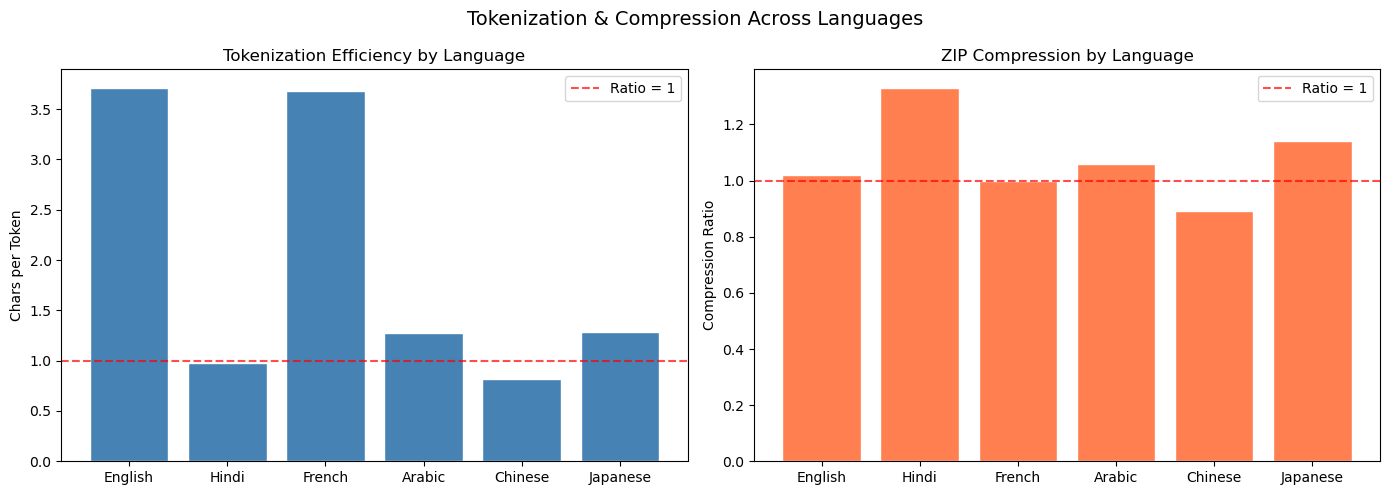

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

languages = df["Language"].tolist()
x = np.arange(len(languages))

# Token Ratio
axes[0].bar(x, df["Token Ratio"], color="steelblue", edgecolor="white")
axes[0].axhline(y=1, color="red", linestyle="--", alpha=0.7, label="Ratio = 1")
axes[0].set_xticks(x)
axes[0].set_xticklabels(languages)
axes[0].set_ylabel("Chars per Token")
axes[0].set_title("Tokenization Efficiency by Language")
axes[0].legend()

# ZIP Ratio
axes[1].bar(x, df["ZIP Ratio"], color="coral", edgecolor="white")
axes[1].axhline(y=1, color="red", linestyle="--", alpha=0.7, label="Ratio = 1")
axes[1].set_xticks(x)
axes[1].set_xticklabels(languages)
axes[1].set_ylabel("Compression Ratio")
axes[1].set_title("ZIP Compression by Language")
axes[1].legend()

fig.suptitle("Tokenization & Compression Across Languages", fontsize=14)
plt.tight_layout()
plt.show()

* The GPT tokenizer is **most efficient for English and French**.

* It is **less efficient for languages like Hindi, Chinese, and Japanese**, resulting in **more tokens and higher cost**.

* This happens because GPT models are trained primarily on **English-heavy datasets**.

* For non-English languages, **dedicated tokenizers** are often used, which perform **more efficiently and accurately** for those languages.
